# Lab 3: Sentinel-1 Time Series for Crop Growth in Midwest Row-Crop Fields

This notebook is for a lab on seasonal crop growth using Sentinel-1 SAR backscatter in large Midwestern U.S. fields.

The lab is designed to stay fully in Google Earth Engine + Python. We will be:

- building a consistent Sentinel-1 time series,
- selecting individual row-crop fields, forested regions, and towns/cities,
- extracting field-scale backscatter statistics,
- comparing seasonal trajectories,
- proposing a simple crop growth metric based on VV, VH, or VV/VH.

---

## Lab concept

Students will:

1. choose several individual regions in a Midwest US AOI. You do not have to choose a midwest US AOI, but it will be the easiest. Midwest US/Canada has perfectly North/South Aligned farms in 1.5 km grids, which uniformly grow corn/wheat/soy/etc. European farms are much smaller, and randomly oriented. Averaging over an entire field will increase the signal to noise ratio.
2. define field polygons as regions of interest,
3. build a seasonal Sentinel-1 time series,
4. compute field-level summary statistics for:
   - VV
   - VH
   - VV - VH (in dB is a convenient proxy related to VV/VH ratio)
5. interpret how those quantities evolve from:
   - bare ground / early season
   - vegetative growth
   - maturity
   - senescence (interesting fact - senescence progression is monitored via NDVI)
   - harvest

---

## Why the Midwest U.S.?

This is a good teaching region because many fields are:

- large,
- homogeneous,
- easy to outline,
- minimally affected by complex topography,
- dominated by row crops with strong seasonal structure.

That makes field-scale SAR time series much easier to interpret than small, irregular fields. Irregularly oriented fields produce an additional complexity with regards to geometry. You may have noticed when exploring Krakow SAR that the backscatter from farms could vary greatly. This can be due to differences in crop type, but it can also be related to how the rows are oriented with respect to the satellite look direction. Think about the ground texture of farms, there are many small ridges and valleys. If these ridges and valleys are parallel to the satellite look direction, backscatter will be weaker, and if the ridges and valleys are perpendicular to the satellite look direction, backscatter will be stronger.

---

## learning goals

By the end of this lab, students should be able to:

- explain why SAR time series must be filtered consistently,
- compute a field-averaged VV and VH time series,
- compare crop fields with a non-crop control,
- propose and defend simple crop growth metrics,
- explain why VH or VV-VH may respond differently from VV alone.

---

## 1. Imports and Earth Engine initialization

This notebook assumes that students already have:

- a working Python environment,
- the Earth Engine Python API,
- `geemap`,
- libraries `matplotlib` and `pandas`.

In [1]:
import ee
import geemap
import pandas as pd
import json
import matplotlib.pyplot as plt

PROJECT_ID = "fleet-petal-494108-c6"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialized.")

Earth Engine initialized.


## 2. Define an agricultural AOI

This notebook starts with a large AOI in northern Iowa / southern Minnesota.  
You can adjust it later, but it is helpful to begin with a region dominated by large row-crop fields. In one scene, I want you to find a place that has:

- individual crop fields that you can isolate
- A city or town that we're not expecting a strong vegetative growth signal from
- a stand of trees you can isolate

**QUESTION (5pts): Why is the subregion you chose a good choice for exploring crop growth? Trees and crops both have vegetative growth during summer months, but what differences would you expect to see over a year, with regards to VV, VH, and VV-VH? What do you expect to see in the city or town that you have isolated?**

**ANSWER:**
Choosing an area in the Midwest (such as Iowa or Minnesota) is ideal because the large, uniform farm fields allow us to isolate the phenological signal with minimal background noise. Large fields minimize the so-called edge effect, where data from nearby roads or buildings could skew the field’s statistics. On the other hand, selecting a city and forests allows us to verify whether the changes we observe in the fields are actually due to plant growth or perhaps data processing errors (if we also saw growth in the city, we would know that the data is incorrect).

Although both forests and croplands are characterized by a growing season, the main difference between a forest and a cropland lies in the baseline and the amplitude of changes throughout the year.
A field in the early season has low VH and moderate VV, and as plants grow, VH values increase, sometimes quite rapidly. After harvest, however, this value decreases day by day (bare soil).
In the case of forests, however, the baseline is significantly higher - they have a constant structure, so the signal remains relatively stable at all times because tree biomass is always present.

Unlike biological systems, any variation in the town is likely due to moisture or changes in satellite viewing geometry, providing a perfect static control to verify that our data processing is consistent.


In [2]:
# Example AOI: large row-crop region in northern Iowa / southern Minnesota
aoi = ee.Geometry.Rectangle([-93.95, 43.65, -93.25, 44.15])

# Growing season year
YEAR = 2025

# Visualization parameters
vv_vis = {"min": -18, "max": 2}
vh_vis = {"min": -28, "max": -8}
ratio_vis = {"min": 2, "max": 12}

m = geemap.Map(center=[43.9, -93.6], zoom=11)
m.addLayer(aoi, {"color": "red"}, "AOI")
m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 3. Helper functions

To keep the notebook readable, the repetitive Earth Engine logic is collected into helper functions.

These functions do most of the work for:

- building a filtered Sentinel-1 collection,
- creating monthly composites,
- computing a convenient VV-VH metric,
- extracting region statistics through time.

---

### Why use `VV - VH` here?

Sentinel-1 GRD backscatter in Earth Engine is in dB.  
So for this lab, instead of using a raw linear ratio `VV/VH`, we use:

\[
VV - VH
\]

because in dB space this is directly related to the log-ratio and is easier to interpret consistently alongside VV and VH.


In [3]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass="ASCENDING",
                      mode="IW",
                      resolution=10):
    """Return a filtered Sentinel-1 GRD collection with VV and VH."""
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .select(["VV", "VH"])
    )
    return collection


def monthly_composite(year, month, region=aoi):
    """Return a monthly median Sentinel-1 image with a derived VV-VH band."""
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    vv_minus_vh = image.select("VV").subtract(image.select("VH")).rename("VV_minus_VH")

    return (
        image.addBands(vv_minus_vh)
        .set({
            "year": year,
            "month": month,
            "system:time_start": start.millis(),
            "scene_count": collection.size()
        })
    )


def build_monthly_stack(year, months=range(3, 11), region=aoi):
    """Create a monthly ImageCollection for a growing season."""
    images = [monthly_composite(year, month, region=region) for month in months]
    return ee.ImageCollection(images)


def region_time_series(image_collection, region, scale=10):
    """Extract field-level mean VV, VH, and VV_minus_VH through time.

    Accepts either an ee.Geometry or an ee.Feature.
    """
    # If region is a Feature, convert it to its geometry
    if isinstance(region, ee.feature.Feature):
        region = region.geometry()

    def per_image(img):
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=scale,
            maxPixels=1e9,
            bestEffort=True
        )
        return ee.Feature(None, {
            "date": ee.Date(img.get("system:time_start")).format("YYYY-MM-dd"),
            "year": img.get("year"),
            "month": img.get("month"),
            "scene_count": img.get("scene_count"),
            "VV": stats.get("VV"),
            "VH": stats.get("VH"),
            "VV_minus_VH": stats.get("VV_minus_VH")
        })

    return ee.FeatureCollection(image_collection.map(per_image))

def fc_to_df(fc):
    """Convert an Earth Engine FeatureCollection of stats into a pandas DataFrame."""
    data = fc.getInfo()["features"]
    rows = [f["properties"] for f in data]
    df = pd.DataFrame(rows)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df


## 4. Build a seasonal Sentinel-1 time series

We build monthly median images from February through November.

**QUESTION (5pts): What are the advantages and disadvantages of using monthly median stacks instead of relying on single scenes? In what circumstances would you not want to do any temporal averaging, and instead rely on single scenes?**

**ANSWER:**
Using monthly median stacks is a great way to clean up data because SAR imagery is naturally noisy due to a phenomenon called speckle, which looks like salt-and-pepper graininess. By taking the median, we effectively filter out this noise and remove temporary outliers, such as a heavy rain event on a specific day that might temporarily spike the backscatter. However, the downside is that we lose "temporal resolution", so we won't see exactly when a farmer harvested a field or how a flash flood affected the soil. Temporal averaging should be avoided if monitoring rapid events, like tracking active flood progression, identifying the exact day of a crop harvest.

**QUESTION (5pts): Why do we filter Sentinel-1 by orbit direction, instrument mode, polarization, and resolution before building the time series? What might happen if ascending and descending passes were mixed in the same time series?**

**ANSWER:**
We filter parameters for Sentinel-1 to ensure we are comparing  same type of data throughout the year. SAR is an active sensor that looks at the ground from a specific angle, so the geometry of the observation matters immensely. If we mix ascending and descending passes, the satellite is looking at the same field from opposite directions. Since row crops and topography have 3D structures, the backscatter intensity can change just because of the viewing angle, not because the crop actually grew. Mixing them would create a stranege pattern in time series, making it look like the vegetation is wildly fluctuating every few days when, in reality, it is just the sensor's perspective changing. Keeping the mode and resolution consistent ensures that the level of detail and the way the radar wave interacts with the canopy remains stable for the whole study.

In [4]:
months = list(range(2, 12))  # February through November
monthly_stack = build_monthly_stack(YEAR, months=months, region=aoi)

print("Monthly images in stack:", monthly_stack.size().getInfo())

# Check how many scenes contribute to each month
for month in months:
    img = monthly_composite(YEAR, month, aoi)
    print(f"Month {month:02d}: {ee.Number(img.get('scene_count')).getInfo()} scenes")


Monthly images in stack: 10
Month 02: 8 scenes
Month 03: 8 scenes
Month 04: 10 scenes
Month 05: 4 scenes
Month 06: 3 scenes
Month 07: 3 scenes
Month 08: 4 scenes
Month 09: 2 scenes
Month 10: 4 scenes
Month 11: 4 scenes


## 5. Quick visual inspection

Before drawing fields, it is useful to inspect one or two monthly composites.

Suggested things to look for:

- field texture,
- strong contrasts between different fields,
- stable non-crop controls such as roads, towns, or tree patches.

**QUESTION (10pts): Compare an early month with a peak month visually. Feel free to change the months plotted, or add in comparisons of early vs mid- season VV_minus_VH, for your investigations. Take particular note of how much VH changes vs how much VV changes. What regions do you think you will choose for your ROI's and why? If you want an extra challenge (but not necessary), try to find a field you think was tall crops, a field you think was short crops, and a field you think was left barren.**

**ANSWER:**
When comparing the February and July (peak) composites, the most striking observation is that the VH band shows a much greater dynamic range over the growing season than the VV band. In February, the entire agricultural landscape looks really dark and uniform in VH because the flat, frozen, or bare ground offers very little volume scattering. By July, these same fields brighten significantly in VH (and look like a different place!!). This is because the developed crop creates a complex 3D structure that depolarizes the radar signal, sending a much stronger VH return back to the satellite. While VV also increases as the plants grow, it is more sensitive to soil moisture and the vertical structure of the stems, making its seasonal "jump" feel a little less dramatic than the VH signal's response to the overall increase in biomass.

For my Regions of Interest (ROIs), I will choose a set of large, rectangular fields in the center of the AOI to capture the primary crop signal. I am selecting these because their uniform brightness in July suggests a healthy, consistent canopy.

In [5]:
img_early = monthly_composite(YEAR, 2, aoi)
img_peak = monthly_composite(YEAR, 7, aoi)

#YOUR CODE HERE: The lines above grab the montlhy composite images for February and July. I want you to plot a split_map image of the VH channel in this cell, and in the cell below plot a split_map image of the VV channel for the same months.
m_vh = geemap.Map(center=[43.9, -93.6], zoom=11)
m_vh.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VH"), vh_vis, "VH February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VH"), vh_vis, "VH July")
)
display(m_vh)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

In [6]:
# VV Channel Split Map
m_vv = geemap.Map(center=[43.9, -93.6], zoom=11)
m_vv.split_map(
    left_layer=geemap.ee_tile_layer(img_early.select("VV"), vv_vis, "VV February"),
    right_layer=geemap.ee_tile_layer(img_peak.select("VV"), vv_vis, "VV July")
)
display(m_vv)

Map(center=[43.9, -93.6], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

# 6. Draw field polygons

Use the map drawing tools to create several polygons:

- at least **two different crop fields**
- at least **two control areas** (1 patch of trees, 1 city or town)

### Suggested strategy
Pick fields that are:

- large,
- internally uniform,
- clearly separated from neighboring fields.

After drawing polygons on the map, export them to Earth Engine objects.

**NOTE: You will need to remember the order of the ROI's you chose. For example, remember that you first chose three farm fields, then a tree stand, then the city/town. In the next section, you will need to assign these drawn features to variables and a dictionary.**



In [7]:
m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
m.addLayer(img_peak.select("VH"), vh_vis, "VH July")
#m.addLayer(aoi, {"color": "red"}, "AOI")
m

# After drawing polygons with the map tools, use:
# drawn_fc = m.draw_features

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [10]:
drawn_fc = m.draw_features
print(drawn_fc)

[<ee.feature.Feature object at 0x000001F6A6A5A180>, <ee.feature.Feature object at 0x000001F6A6B9AFF0>, <ee.feature.Feature object at 0x000001F6A6B99220>, <ee.feature.Feature object at 0x000001F6A6B9AC00>, <ee.feature.Feature object at 0x000001F6A6B996A0>, <ee.feature.Feature object at 0x000001F6A6B98F80>, <ee.feature.Feature object at 0x000001F6A6B9ABD0>]


## 7. Make sure your drawn features are where you want them.

To do this, you will need to need to adjust the code below to match the order and number of ROI's you chose to investigate.


In [11]:
# Extract the drawn features based on the exact order you drew them:
# 3 fields (0, 1, 2) -> 2 cities (3, 4) -> 2 forests (5, 6)

field_1   = drawn_fc[0]
field_2   = drawn_fc[1]
field_3   = drawn_fc[2]
city_1    = drawn_fc[3]
city_2    = drawn_fc[4]
forest_1  = drawn_fc[5]
forest_2  = drawn_fc[6]

# Consolidate all 7 areas into the final dictionary
roi_dict = {
    "Field_1": field_1,
    "Field_2": field_2,
    "Field_3": field_3,
    "City_1": city_1,
    "City_2": city_2,
    "Forest_1": forest_1,
    "Forest_2": forest_2
}

# Display the map with your designated shapes highlighted in yellow
m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_peak.select("VV"), vv_vis, "VV July")
for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)
display(m)

## PLEASE PASTE THE OUTPUT OF THIS AS A COMMENT HERE SO THAT I KNOW WHICH ROI's YOU CHOSE
# This loop converts your features safely to geometries and prints their coordinates.
for name, roi in roi_dict.items():
    # Using geemap's structure to dynamically handle features/geometries
    geom = roi.geometry() if hasattr(roi, 'geometry') else roi
    print(name, geom.getInfo())

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

Field_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.637321, 43.87704], [-93.635562, 43.877164], [-93.632342, 43.875029], [-93.6326, 43.866397], [-93.637751, 43.866026], [-93.637321, 43.87704]]]}
Field_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.63715, 43.898567], [-93.637021, 43.89535], [-93.627364, 43.89535], [-93.627579, 43.898721], [-93.63715, 43.898567]]]}
Field_3 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.556369, 43.920574], [-93.547183, 43.920574], [-93.547441, 43.899241], [-93.556283, 43.899117], [-93.556369, 43.920574]]]}
City_1 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.274411, 44.094909], [-93.257328, 44.09497], [-93.256813, 44.09084], [-93.273123, 44.090162], [-93.274411, 44.094909]]]}
City_2 {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-93.2763, 44.068335], [-93.272351, 44.06815], [-93.272608, 44.073576], [-93.276214, 44.073823], [-93.2763, 44.068335]]]}
Forest_1 {'geodesic': False, 'type': 

## 8. Extract time series for each field

For each ROI, compute a field-mean time series of:

- VV
- VH
- VV - VH

This is the core analysis step of the lab.

In [15]:
ts_dict = {}

for name, geom in roi_dict.items():
    fc = region_time_series(monthly_stack, geom, scale=10)
    df = fc_to_df(fc)
    ts_dict[name] = df

for name, df in ts_dict.items():
    print(f"\n=== table for: {name} ({len(df)} monthly points) ===")
    display(df)




=== table for: Field_1 (10 monthly points) ===


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-31.894243,-18.144733,13.749510,2025-02-01,2,8,2025
1,-23.720894,-13.248071,10.472823,2025-03-01,3,8,2025
2,-28.060099,-15.459691,12.600408,2025-04-01,4,10,2025
3,-24.781121,-13.865464,10.915657,2025-05-01,5,4,2025
4,-24.856761,-13.661345,11.195416,2025-06-01,6,3,2025
5,-20.476893,-12.419917,8.056976,2025-07-01,7,3,2025
6,-16.277661,-9.522222,6.755439,2025-08-01,8,4,2025
7,-18.465112,-10.560866,7.904245,2025-09-01,9,2,2025
8,-20.256355,-10.974100,9.282255,2025-10-01,10,4,2025
9,-21.878413,-12.125972,9.752441,2025-11-01,11,4,2025



=== table for: Field_2 (10 monthly points) ===


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-30.887708,-18.394319,12.493389,2025-02-01,2,8,2025
1,-21.794912,-13.835884,7.959028,2025-03-01,3,8,2025
2,-23.785209,-15.275566,8.509642,2025-04-01,4,10,2025
3,-23.397298,-15.342191,8.055107,2025-05-01,5,4,2025
4,-20.594013,-14.141646,6.452366,2025-06-01,6,3,2025
5,-18.294673,-12.860501,5.434172,2025-07-01,7,3,2025
6,-18.725946,-12.978326,5.747620,2025-08-01,8,4,2025
7,-19.434741,-13.334522,6.100218,2025-09-01,9,2,2025
8,-20.359728,-13.795510,6.564218,2025-10-01,10,4,2025
9,-23.695900,-15.304851,8.391049,2025-11-01,11,4,2025



=== table for: Field_3 (10 monthly points) ===


...

,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-22.570198,-10.569040,12.001158,2025-02-01,2,8,2025
1,-20.788581,-8.810389,11.978192,2025-03-01,3,8,2025
2,-21.853167,-10.434760,11.418406,2025-04-01,4,10,2025
3,-22.465522,-10.773588,11.691935,2025-05-01,5,4,2025
4,-22.138586,-11.000252,11.138334,2025-06-01,6,3,2025
5,-22.292673,-10.766014,11.526659,2025-07-01,7,3,2025
6,-22.253226,-11.246608,11.006618,2025-08-01,8,4,2025
7,-22.057596,-10.537213,11.520384,2025-09-01,9,2,2025
8,-22.655960,-11.109412,11.546548,2025-10-01,10,4,2025
9,-22.774543,-11.147794,11.626749,2025-11-01,11,4,2025



=== table for: Forest_1 (10 monthly points) ===


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-19.209214,-12.100554,7.108660,2025-02-01,2,8,2025
1,-13.843149,-8.360995,5.482155,2025-03-01,3,8,2025
2,-14.430210,-8.779898,5.650312,2025-04-01,4,10,2025
3,-14.358670,-8.466863,5.891807,2025-05-01,5,4,2025
4,-15.203106,-8.693652,6.509454,2025-06-01,6,3,2025
5,-15.438652,-8.831563,6.607089,2025-07-01,7,3,2025
6,-15.929977,-9.256686,6.673291,2025-08-01,8,4,2025
7,-15.768287,-9.056934,6.711354,2025-09-01,9,2,2025
8,-15.124919,-9.114579,6.010340,2025-10-01,10,4,2025
9,-15.666220,-9.607022,6.059197,2025-11-01,11,4,2025



=== table for: Forest_2 (10 monthly points) ===


,VH,VV,VV_minus_VH,date,month,scene_count,year
0,-21.167625,-13.040253,8.127373,2025-02-01,2,8,2025
1,-14.867190,-8.593846,6.273345,2025-03-01,3,8,2025
2,-15.695142,-9.445106,6.250036,2025-04-01,4,10,2025
3,-15.462638,-9.099011,6.363627,2025-05-01,5,4,2025
4,-15.901860,-9.033471,6.868388,2025-06-01,6,3,2025
5,-15.654742,-9.081834,6.572909,2025-07-01,7,3,2025
6,-16.247829,-9.696676,6.551153,2025-08-01,8,4,2025
7,-16.236958,-9.521059,6.715899,2025-09-01,9,2,2025
8,-15.559205,-9.319295,6.239910,2025-10-01,10,4,2025
9,-16.524399,-10.141642,6.382757,2025-11-01,11,4,2025


**QUESTION (5pts): Which month has the minimum VH? Which month has the maximum VH? Does this match what you expected from the image comparison?**

**ANSWER:**
The minimum VH occurs in February for all three selected fields, while the maximum VH occurs in August for Field 1 and in July for Fields 2 and 3. This is consistent with the visual assessment, the numerical difference between February and July/August in cultivated fields is as high as 14 to 15 dB, which is a striking amplitude.

The graphs for cities, however, are very flat and stable (from -19 dB to -22 dB), and for vv around -9 dB and -11 dB.

For forests, differences are visible in February (-19 to -21 dB) compared to March, where this value jumps to -13 to -14 dB and remains so throughout the summer; the change, however, is milder than for farmland.


## 9. Plot VV, VH, and VV-VH through time

These plots are where the crop-growth story should begin to emerge.

**QUESTION (20pts):**
- Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.
- Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.
- Does VV-VH separate crops from control AOI's better than VV alone?
- Which ROI looks least like an actively growing crop field?
- Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.

**ANSWER:**
- **Qualitatively compare your three different types of ROI's (1) farms; (2) trees; and (3) towns. A few sentences to a short paragraph is enough.**

Farms (1,2,3) szhow high dynamic U-shaped/bell-shaped trajectory. Starting with low backscatter in winter, rising sharply during the summer due to biomass accumulation, then experiencing a big drop-off in autumn. 

Trees (forests) occupy highest backscatter values for both VV and VH. They remains stable and constantly elevated, aside from a sharp bounce between Feb and March. 

Cities present flat across all three plots, becouse of unyielding, vertical, urban structures, which produce strong double bounce scattering, but is immune to seasonal changes.

- **Based on these plots, identify the months that (1) crops started growing; (2) crops stopped growing; and (3) crops were harvested.**

Crops started growing from May to June -> until May, fields 1 and 2 are flat or dipping. Between May and June, we see a upward pivot in VH and a simultaneous dive down in the VV - VH ratio, marking the emergence of vegetative structures. 

Crops stopped growing in July to August ->the curves flatten out at their absolute highest VH levels and lowest VV - VH ratio levels during these months, so the plants are the most mature = stabilization. 

Crops were harvested from September to October -> sharp decline in VH backscatter and a rapid rebound in the VV - VH ratio as fields are stripped of their biomass, bare soil.

- **Does VV-VH separate crops from control AOI's better than VV alone?**

Yes, looking at the top chart (VV), the crop lines mix and cross directly through the city and forest control profiles. For example, in July and August, Field 3's VV signature completely overlaps with City 1 and Forest 2, making separation very difficult. In contrast, the bottom chart (VV - VH) provides a much cleaner diagnostic window. During the peak of the growing season, the fields separate cleanly and dive down into cluster between 5.5dB and 8dB, completely detached from the urban controls.

- **Which ROI looks least like an actively growing crop field?**

City 2 looks the absolute least like a growing field. It behaves as a near-perfect flat line across the entire ten-month span.

- **Which ROI shows the strongest seasonal change in VH? Which ROI is most stable through time? Explain whether each behavior is more consistent with crop growth, forest canopy, or built-up land.**

Strongest Seasonal Change = Field 1 -> displays a massive dynamic range, climbing from a winter low, up to a summer peak. This extreme change is entirely consistent with crop growth, where a patch of ground transitions from completely bare, flat soil to a dense, high-biomass jungle of plants.

Most Stable Through Time = City 2 (followed by City 1). It varies by barely 1 dB all year long, because of zero biological growth, leaf loss, or harvest cycles.

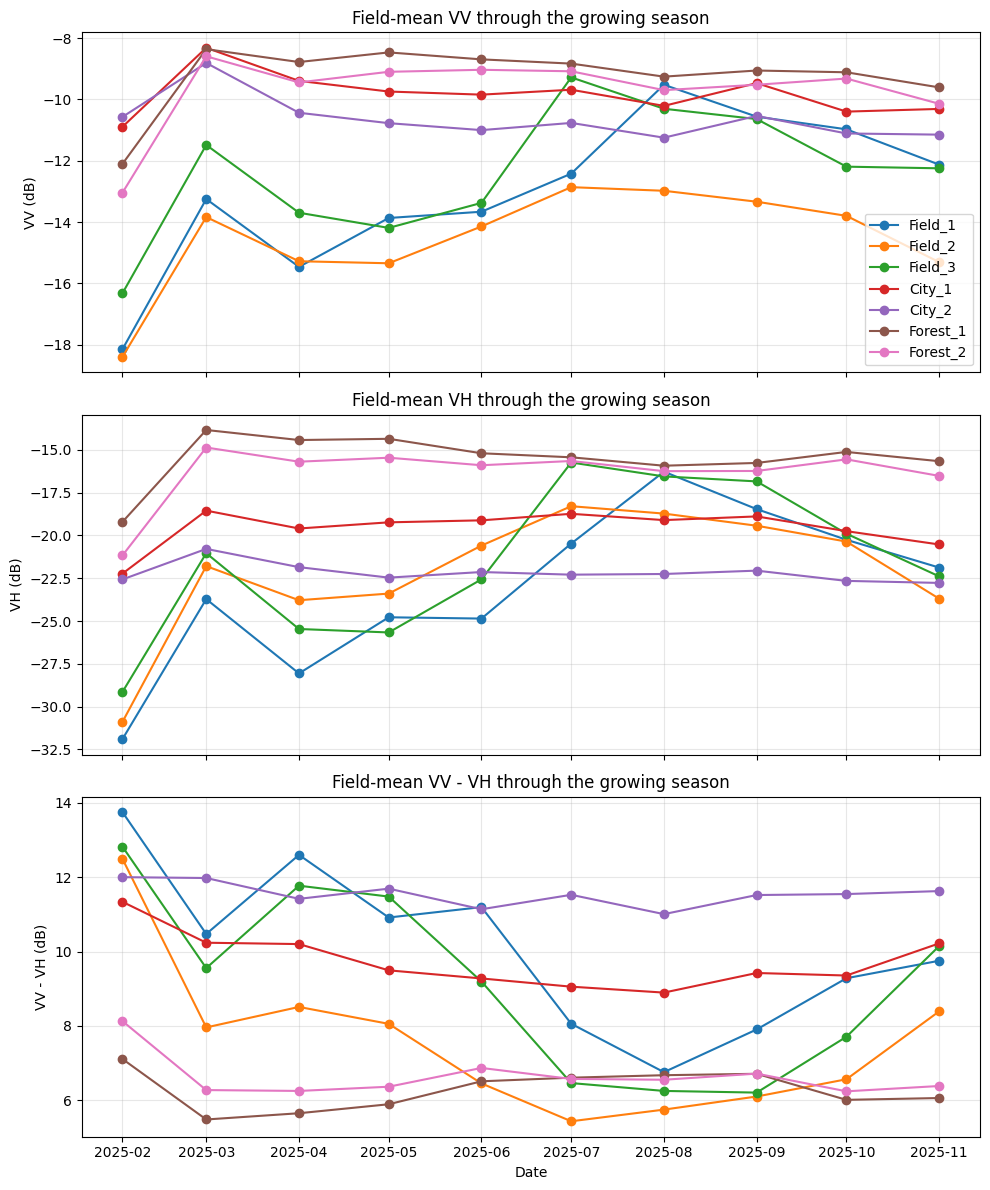

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

for name, df in ts_dict.items():
    axes[0].plot(df["date"], df["VV"], marker="o", label=name)
    axes[1].plot(df["date"], df["VH"], marker="o", label=name)
    axes[2].plot(df["date"], df["VV_minus_VH"], marker="o", label=name)

axes[0].set_title("Field-mean VV through the growing season")
axes[0].set_ylabel("VV (dB)")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Field-mean VH through the growing season")
axes[1].set_ylabel("VH (dB)")
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Field-mean VV - VH through the growing season")
axes[2].set_ylabel("VV - VH (dB)")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()


## 10. Build a simple crop-growth metric

Next I want you to propose a metric that captures crop development.

Possible first ideas include:

- peak VH minus spring VH,
- July VH minus April VH,
- maximum seasonal VV-VH range,
- cumulative increase from planting to peak growth.

Below is one simple example:

\[
Growth Metric = VH_{peak} - VH_{early}
\]

This is not necessarily the best metric — it is just a starting point.



TABLE OF ADVANCED RADAR METRICS


,ROI,Peak_Month,VH_Range (dB),Biomass_Explosion (dB),Structure_Shift_Drop (dB),Radar_Stability_STD,Type
0,Field_1,8,15.62,11.78,5.36,4.63,Farm
1,Field_2,7,12.59,5.49,4.79,3.69,Farm
2,Field_3,7,13.40,9.72,4.94,4.41,Farm
3,City_1,7,3.68,0.86,1.89,1.09,Town
4,City_2,8,1.99,-0.40,0.98,0.57,Town
5,Forest_1,7,5.37,-1.01,-0.31,1.47,Forest
6,Forest_2,7,6.30,0.04,0.65,1.76,Forest


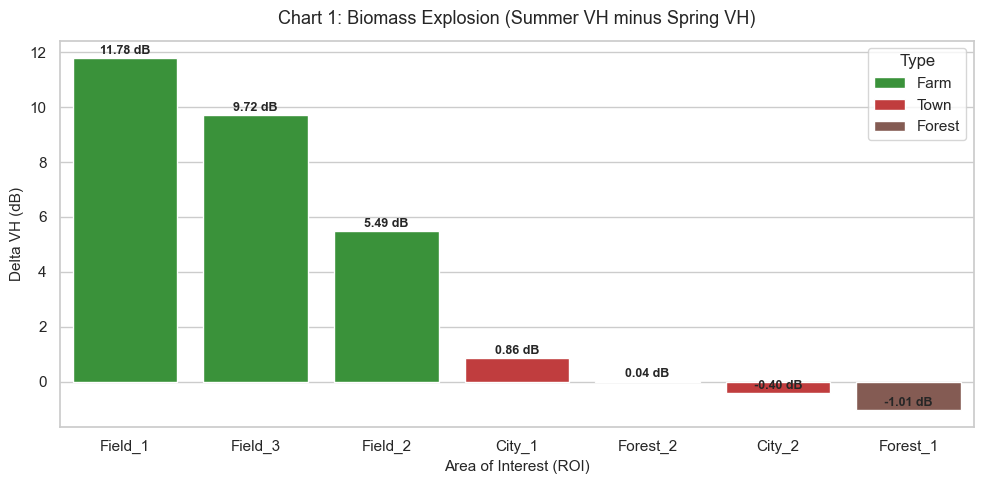

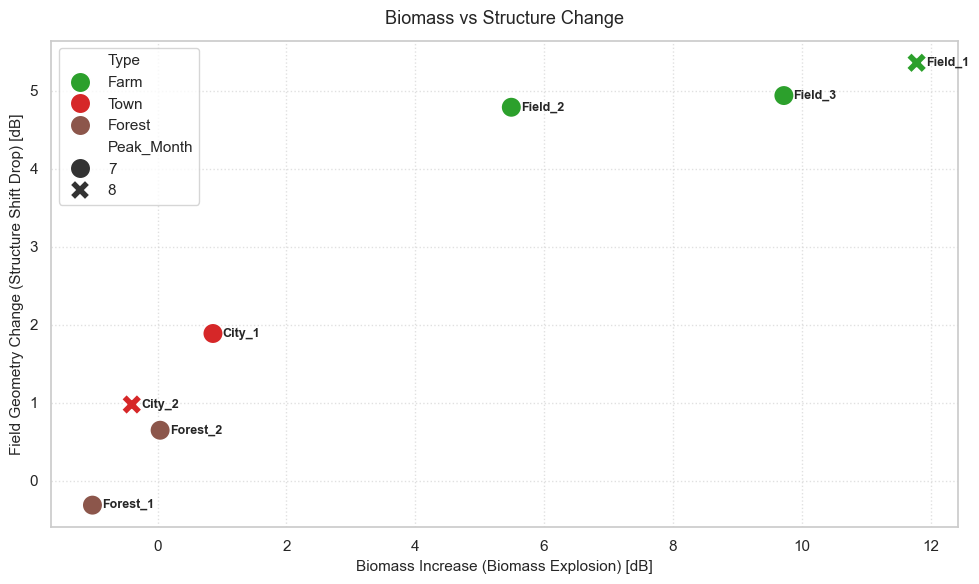

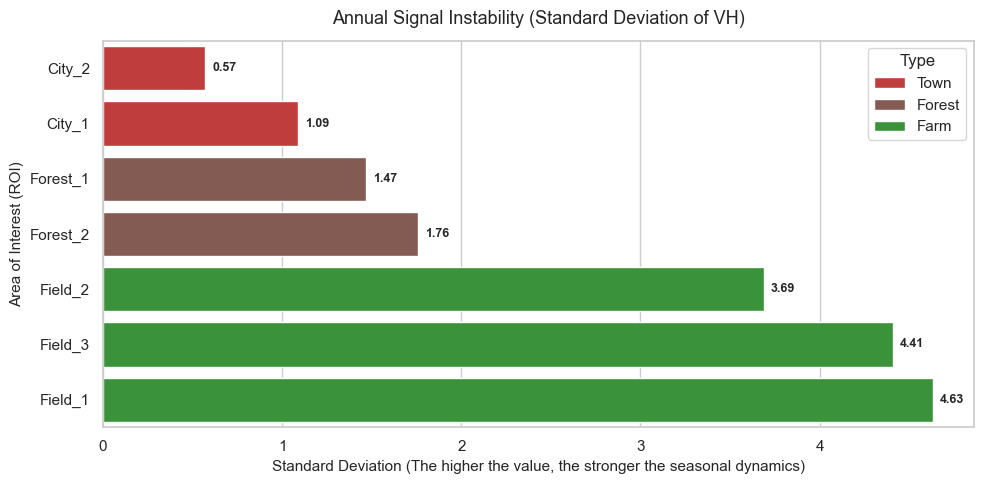

In [22]:
##YOUR CODE HERE (50pts)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def compute_advanced_radar_metrics(ts_dictionary):
    advanced_results = []
    
    for name, df in ts_dictionary.items():
        df = df.sort_values("month").reset_index(drop=True)
        
        #key time points
        df_spring = df[df['month'] == 4]  #april (spring)
        df_winter = df[df['month'].isin([2, 3])]  #feb/mar (early season)
        df_summer = df[df['month'].isin([7, 8])]  #july/august (peak)
        
        if df_spring.empty or df_summer.empty or df_winter.empty:
            continue
            
        vh_early = df_spring['VH'].values[0]
        
        #finding peak of biomass (max VH in summer)
        idx_peak = df_summer['VH'].idxmax()
        peak_row = df.loc[idx_peak]
        
        peak_month = int(peak_row['month'])
        vh_peak = peak_row['VH']
        
        #calc explosion
        vh_biomass_explosion = vh_peak - vh_early
        
        #change in structure (Winter vs Summer)
        vv_minus_vh_winter = df_winter['VV_minus_VH'].mean()
        vv_minus_vh_summer = df_summer['VV_minus_VH'].min()
        structure_shift_drop = vv_minus_vh_winter - vv_minus_vh_summer
        
        #complete variability (max - min)
        vh_range = df['VH'].max() - df['VH'].min()
        
        #stability (standard deviation)
        vh_stability_std = df['VH'].std()
        
        advanced_results.append({
            "ROI": name,
            "Peak_Month": peak_month,
            "VH_Range (dB)": round(vh_range, 2),
            "Biomass_Explosion (dB)": round(vh_biomass_explosion, 2),
            "Structure_Shift_Drop (dB)": round(structure_shift_drop, 2),
            "Radar_Stability_STD": round(vh_stability_std, 2)
        })
        
    return pd.DataFrame(advanced_results)

###################
metrics_df = compute_advanced_radar_metrics(ts_dict)

def get_label(roi):
    if "Field" in roi: return "Farm"
    if "Forest" in roi: return "Forest"
    return "Town"
metrics_df['Type'] = metrics_df['ROI'].apply(get_label)

color_palette = {"Farm": "#2ca02c", "Forest": "#8c564b", "Town": "#d62728"}

print("TABLE OF ADVANCED RADAR METRICS")
display(metrics_df)


sns.set_theme(style="whitegrid")
#Biomass Explosion (Bar Plot)
plt.figure(figsize=(10, 5))
metrics_sorted_bar = metrics_df.sort_values(by="Biomass_Explosion (dB)", ascending=False)
ax1 = sns.barplot(x="ROI", y="Biomass_Explosion (dB)", hue="Type", data=metrics_sorted_bar, palette=color_palette, dodge=False)
plt.title("Chart 1: Biomass Explosion (Summer VH minus Spring VH)", fontsize=13, pad=12)
plt.ylabel("Delta VH (dB)", fontsize=11)
plt.xlabel("Area of Interest (ROI)", fontsize=11)
for p in ax1.patches:
    if p.get_height() != 0:
        ax1.annotate(f"{p.get_height():.2f} dB", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

#Radar Feature Space (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Biomass_Explosion (dB)", y="Structure_Shift_Drop (dB)", hue="Type", style="Peak_Month", s=220, data=metrics_df, palette=color_palette)
for i in range(metrics_df.shape[0]):
    plt.text(x=metrics_df["Biomass_Explosion (dB)"][i] + 0.15, y=metrics_df["Structure_Shift_Drop (dB)"][i], s=metrics_df["ROI"][i], fontweight='semibold', verticalalignment='center', fontsize=9)
plt.title("Biomass vs Structure Change", fontsize=13, pad=12)
plt.xlabel("Biomass Increase (Biomass Explosion) [dB]", fontsize=11)
plt.ylabel("Field Geometry Change (Structure Shift Drop) [dB]", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

#Radar Stability - Standard Deviation
plt.figure(figsize=(10, 5))
metrics_sorted_std = metrics_df.sort_values(by="Radar_Stability_STD", ascending=True)
ax3 = sns.barplot(x="Radar_Stability_STD", y="ROI", hue="Type", data=metrics_sorted_std, palette=color_palette, dodge=False)
plt.title("Annual Signal Instability (Standard Deviation of VH)", fontsize=13, pad=12)
plt.xlabel("Standard Deviation (The higher the value, the stronger the seasonal dynamics)", fontsize=11)
plt.ylabel("Area of Interest (ROI)", fontsize=11)
for p in ax3.patches:
    if p.get_width() != 0:
        ax3.annotate(f"{p.get_width():.2f}", (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Optional: compare fields spatially for one month

It is often useful to look at the mapped field values in the month of strongest contrast.

This can help connect your field-average statistics back to the actual imagery.


In [18]:
img_july = monthly_composite(YEAR, 7, aoi)

m = geemap.Map(center=[43.9, -93.6], zoom=12)
m.addLayer(img_july.select("VV"), vv_vis, "VV July")
m.addLayer(img_july.select("VH"), vh_vis, "VH July")
m.addLayer(img_july.select("VV_minus_VH"), ratio_vis, "VV-VH July")

for name, geom in roi_dict.items():
    m.addLayer(geom, {"color": "yellow"}, name)

m

Map(center=[43.9, -93.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

## 12. Optional: identify likely tall vs shorter crops

With Sentinel-1 alone, you should not make an overconfident crop-type classification.  
But you can propose that one field is more consistent with a tall, strongly volume-scattering canopy than another.

For example:
- stronger seasonal VH increase,
- larger mid-season drop in VV-VH,
- more pronounced growth curve.


## Final note
This lab is designed to connect a simple SAR observable to a real seasonal process.  
The goal is not perfect crop classification, but rather to help reason from:

- backscatter,
- polarization,
- time,
- and field geometry

toward a physically grounded interpretation of crop growth.
